In [123]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np
from statsmodels.tsa.stattools import acf

# Dados

In [43]:
database = pd.read_csv("C:/Users/aless/Downloads/dados_segurança.csv")

database['date'] = database.apply(lambda row: datetime(row['ano'], row['mes'], 1), axis=1)
database = database.set_index('date')

In [21]:
locations = database[['id_cisp','unidade_territorial']].set_index('id_cisp')['unidade_territorial'].to_dict()
locations

{15: 'Gávea; Jardim Botânico; Lagoa; São Conrado e Vidigal',
 10: 'Botafogo; Humaitá e Urca'}

## Escolha de variáveis

In [ ]:
# variaveis = ['quantidade_pessoas_desaparecidas','quantidade_encontro_cadaver','quantidade_extorsao','quantidade_furto_coletivo',
#       'quantidade_roubo_residencia','quantidade_roubo_comercio','quantidade_homicidio_culposo','quantidade_estupro',
#        'quantidade_tentativa_homicidio','quantidade_homicidio_doloso']

In [107]:
variaveis = ['quantidade_encontro_cadaver','quantidade_extorsao',
      'quantidade_roubo_residencia','quantidade_homicidio_culposo','quantidade_estupro',
       'quantidade_tentativa_homicidio']

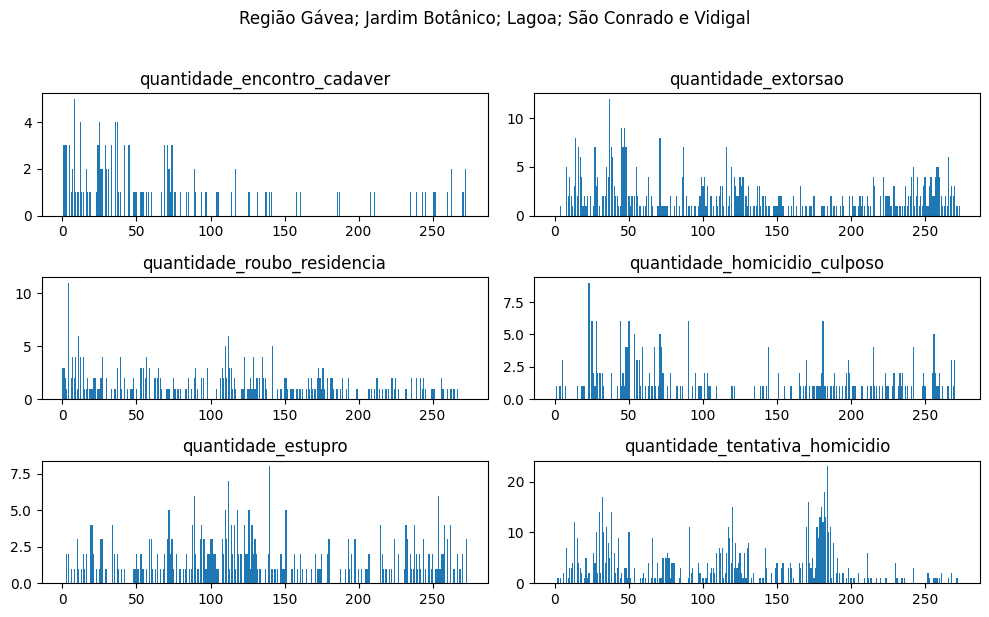

In [110]:
data = database.loc[database.id_cisp==15, variaveis]
n_var = len(variaveis)

nrows = (n_var + 1) // 2
fig, ax = plt.subplots(nrows, 2, figsize=(10, 6))

ax = ax.flatten()
for i in range(n_var):
    ax[i].bar(np.arange(data.shape[0]), data.iloc[:, i])
    ax[i].set_title(variaveis[i])

for j in range(n_var, len(ax)):
    fig.delaxes(ax[j])

fig.suptitle('Região {}'.format(locations[15]), y=1.02)
fig.tight_layout()
plt.show()

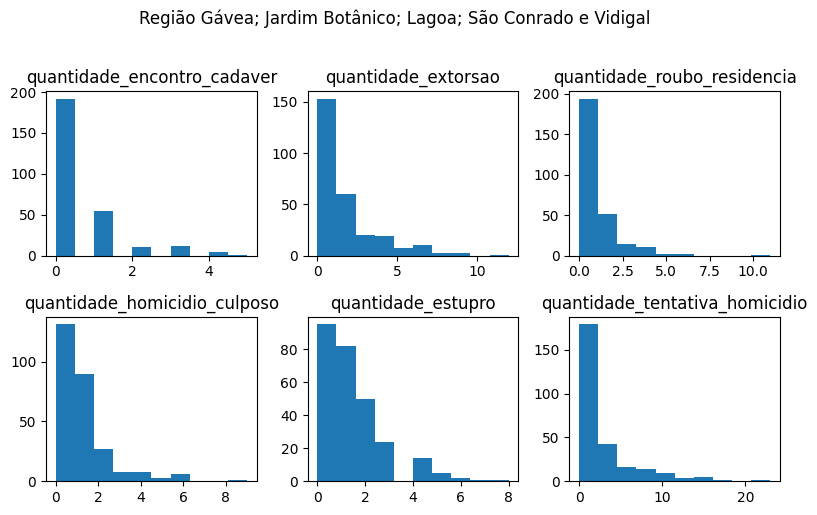

In [78]:
nrows = (n_var + 1) // 3
fig, ax = plt.subplots(nrows, 3, figsize=(8, 5))

ax = ax.flatten()
for i in range(n_var):
    ax[i].hist(data.iloc[:, i])
    ax[i].set_title(variaveis[i])

for j in range(n_var, len(ax)):
    fig.delaxes(ax[j])

fig.suptitle('Região {}'.format(locations[15]), y=1.02)
fig.tight_layout()
plt.show()

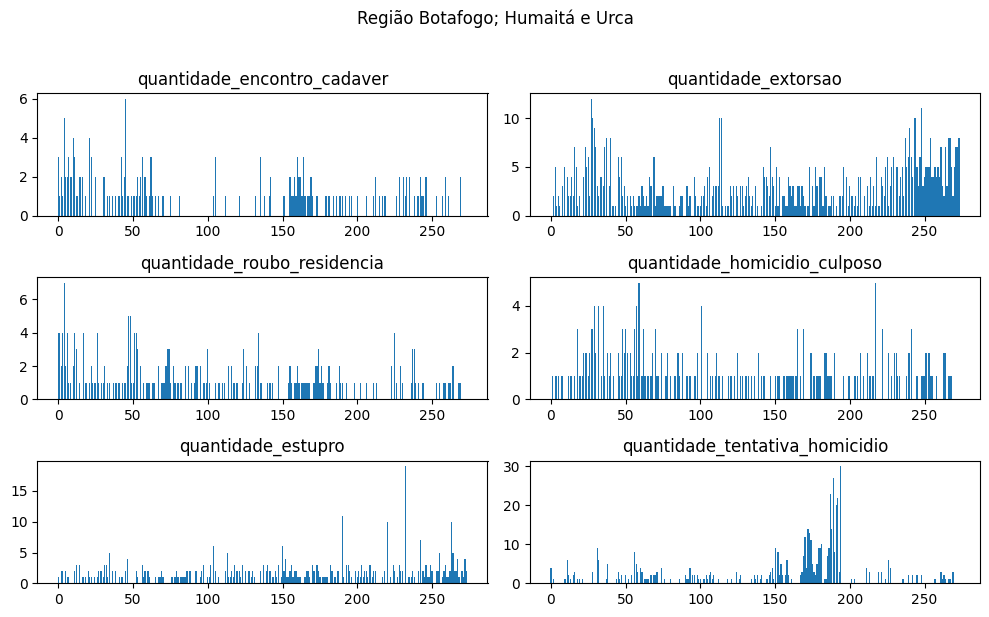

In [109]:
data = database.loc[database.id_cisp==10, variaveis]
n_var = len(variaveis)

nrows = (n_var + 1) // 2
fig, ax = plt.subplots(nrows, 2, figsize=(10, 6))

ax = ax.flatten()
for i in range(n_var):
    ax[i].bar(np.arange(data.shape[0]), data.iloc[:, i])
    ax[i].set_title(variaveis[i])

for j in range(n_var, len(ax)):
    fig.delaxes(ax[j])

fig.suptitle('Região {}'.format(locations[10]), y=1.02)
fig.tight_layout()
plt.show()

## Variável selecionada

In [ ]:
var = 'quantidade_tentativa_homicidio'
data = database.loc[database.id_cisp==10, [var]]

In [128]:
series = data[var]

# metadados
pd.DataFrame(index=['Metadados'], data={
    'Fonte':'Banco de Dados do Instituo de Segurança Pública do Rio de Janeiro (ISP)', 
    'Unidade':'Quantidade de ocorrências',
    'Período da série': '{} a {}'.format(database.index[0].strftime('%d/%m/%Y'), database.index[-1].strftime('%d/%m/%Y'))
}).T

,Metadados
Fonte,Banco de Dados do Instituo de Segurança Públic...
Unidade,Quantidade de ocorrências
Período da série,01/01/2003 a 01/10/2025


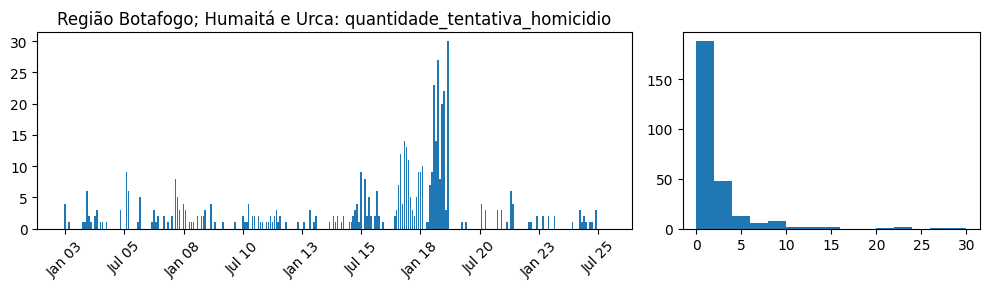

In [138]:
fig, ax = plt.subplots(1, 2, figsize=(10,3), gridspec_kw={"width_ratios": [2, 1]})

ax[0].bar(np.arange(data.shape[0]), data[var])
ticks = np.arange(0, data.shape[0], 30)
ax[0].set_xticks(ticks)
ax[0].set_xticklabels(data.index[ticks].strftime("%b %y"), rotation=45)

ax[1].hist(y, bins=15)

ax[0].set_title(f'Região {locations[10]}: {var}')
plt.tight_layout()
plt.show()

In [129]:
series = series.dropna().astype(int)
prop_zero = (series==0).mean()
mean_ = series.mean()
var_ = series.var(ddof=1)
dispersion = var_/mean_ if mean_>0 else np.inf
autocorr_counts = acf(series, nlags=10, fft=False)  # autocorrelação das contagens
indicator = (series>0).astype(int)
autocorr_indicator = acf(indicator, nlags=10, fft=False)

In [133]:
print(f"prop_zero: {prop_zero:.2f}")
print(f"mean: {mean_:.2f}, var: {var_:.2f}, dispersion (var/mean): {dispersion:.2f}")
print("ACF counts (first 5):", autocorr_counts[:6])
print("ACF indicator (first 5):", autocorr_indicator[:6])

prop_zero: 0.51
mean: 1.90, var: 16.10, dispersion (var/mean): 8.47
ACF counts (first 5): [1.         0.48843057 0.59023983 0.44966942 0.29660534 0.35397205]
ACF indicator (first 5): [1.         0.17113364 0.19685151 0.22971223 0.09476912 0.02539103]
